In [1]:
# Practical 2 - Data Wrangling II
#Ritesh Bhosale

# 1: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# 2: Create Academic Performance Dataset
np.random.seed(10)

data = {
    'Student_ID': range(1, 51),
    'Gender': np.random.choice(['Male', 'Female'], 50),
    'Math_Score': np.random.normal(70, 15, 50),
    'Science_Score': np.random.normal(65, 12, 50),
    'English_Score': np.random.normal(75, 10, 50),
    'Attendance_Percentage': np.random.normal(85, 8, 50),
    'Study_Hours_per_Week': np.random.normal(15, 5, 50)
}

df = pd.DataFrame(data)

df.loc[5, 'Math_Score'] = np.nan
df.loc[10, 'Science_Score'] = np.nan
df.loc[15, 'Attendance_Percentage'] = np.nan

df.loc[20, 'Gender'] = 'male'

df.loc[25, 'Math_Score'] = 200

df.head()

,Student_ID,Gender,Math_Score,Science_Score,English_Score,Attendance_Percentage,Study_Hours_per_Week
0,1,Female,99.947842,69.175418,92.636253,85.444920,21.533846
1,2,Female,53.219927,46.296027,68.491874,98.836680,11.863209
2,3,Male,102.704925,53.059508,73.573145,75.488065,20.445453
3,4,Female,72.857003,96.453830,65.658953,89.786475,7.944093
4,5,Male,88.925288,60.909363,75.265665,91.420528,15.106988


In [5]:
# 3: Handling Missing Values

df.isnull().sum()

df['Math_Score'] = df['Math_Score'].fillna(df['Math_Score'].mean())
df['Science_Score'] = df['Science_Score'].fillna(df['Science_Score'].mean())
df['Attendance_Percentage'] = df['Attendance_Percentage'].fillna(df['Attendance_Percentage'].mean())

print(df['Gender'].unique())

df['Gender'] = df['Gender'].str.capitalize()

['Female' 'Male']


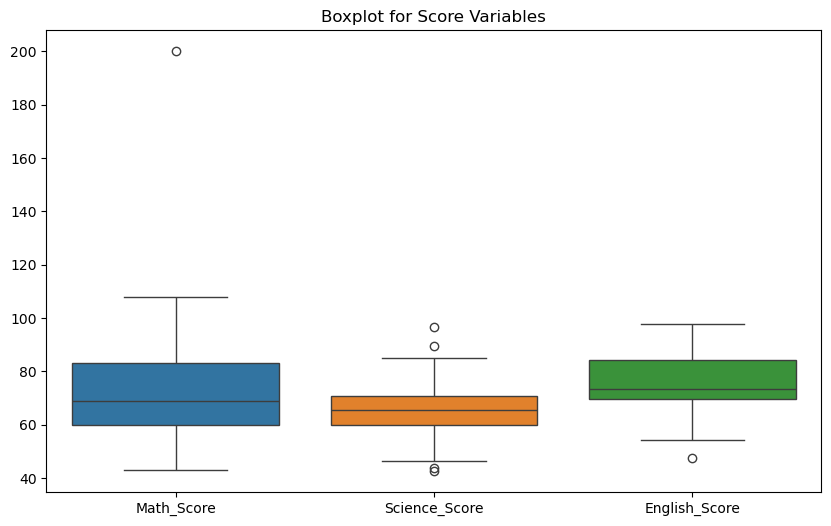

Lower Bound: 25.515429552692744
Upper Bound: 117.62429215267197


In [7]:
# 4: Detect and Treat Outliers

plt.figure(figsize=(10,6))
sns.boxplot(data=df[['Math_Score', 'Science_Score', 'English_Score']])
plt.title("Boxplot for Score Variables")
plt.show()

Q1 = df['Math_Score'].quantile(0.25)
Q3 = df['Math_Score'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

df['Math_Score'] = np.where(df['Math_Score'] > upper_bound, upper_bound, df['Math_Score'])
df['Math_Score'] = np.where(df['Math_Score'] < lower_bound, lower_bound, df['Math_Score'])

Skewness Before: 0.4267636287578622
Skewness After: -0.5289317050813682


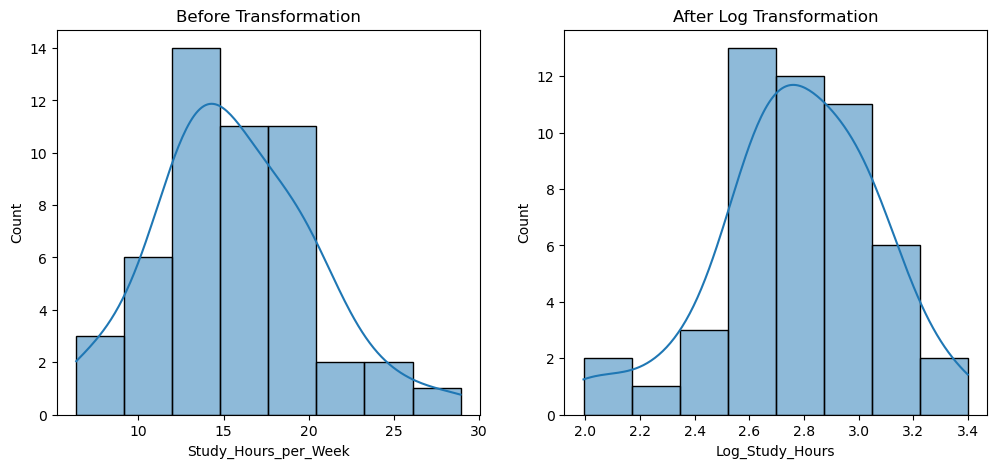

In [8]:
# 5: Data Transformation

print("Skewness Before:", df['Study_Hours_per_Week'].skew())

df['Log_Study_Hours'] = np.log(df['Study_Hours_per_Week'] + 1)

print("Skewness After:", df['Log_Study_Hours'].skew())

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['Study_Hours_per_Week'], kde=True)
plt.title("Before Transformation")

plt.subplot(1,2,2)
sns.histplot(df['Log_Study_Hours'], kde=True)
plt.title("After Log Transformation")

plt.show()